# TASK 1: Inner Workings of ResNet-152

## Importing Libraries

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Dataset Loading and Visualization

In [6]:
image_net_mean = [0.485, 0.456, 0.406]
image_net_std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=image_net_mean,
        std=image_net_std
    )
])

CLASS_NAMES = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

cifar10_trainset = datasets.CIFAR10(root='./data', download=True, train=True, transform=transform)
cifar10_testset = datasets.CIFAR10(root='./data', download=True, train=False, transform=transform)

cifar10_trainloader = DataLoader(cifar10_trainset, batch_size=64, shuffle=True, pin_memory=True)
cifar10_testloader = DataLoader(cifar10_testset, batch_size=64, shuffle=False, pin_memory=True)

Files already downloaded and verified
Files already downloaded and verified


Batch Shape: torch.Size([64, 3, 224, 224])


C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_14360\663523803.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


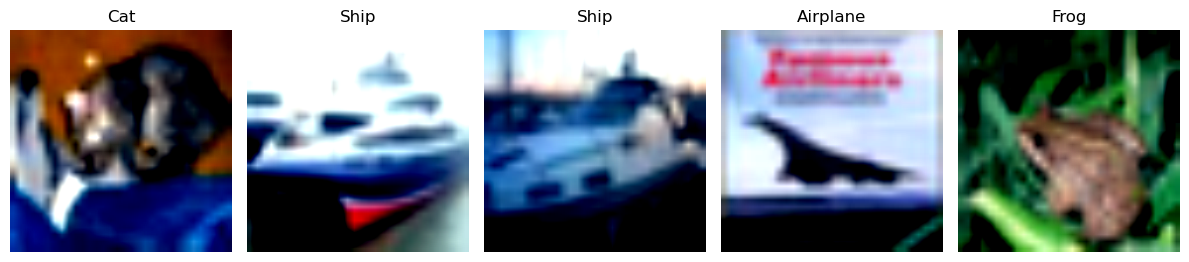

In [7]:
samples, labels = next(iter(cifar10_testloader))
print("Batch Shape:", samples.shape)

fig, axes = plt.subplots(1, 5, figsize=(12, 12))

mean = torch.tensor(image_net_mean).reshape(3, 1, 1)
std = torch.tensor(image_net_std).reshape(3, 1, 1)
for i in range(5):
    img_arr = mean * samples[i] + std
    img_arr = img_arr.clamp(0, 1)
    img_arr = img_arr.permute(1, 2, 0).numpy()
    label = labels[i]
    axes[i].imshow(img_arr)
    axes[i].set_title(CLASS_NAMES[label])
    axes[i].axis('off')

fig.tight_layout()
fig.show()

## 1. Baseline Setup

In [23]:
N_CLASSES = 10
baseline_resnet152 = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

for param in baseline_resnet152.parameters():
    param.requires_grad = False

in_features = baseline_resnet152.fc.in_features
baseline_resnet152.fc = nn.Linear(in_features, N_CLASSES)
baseline_resnet152.fc.requires_grad_(True)
baseline_resnet152.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Training and Evaluation Helper Functions

In [7]:
def train_epoch(model, optimizer, criterion, device):
    model.train(True)

    running_loss = 0
    correct = 0
    total = 0
    for samples, labels in tqdm(cifar10_trainloader):
        batch_size = samples.size(0)
        samples = samples.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(samples)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(output, dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size
        running_loss += loss.item() * batch_size

    avg_loss = running_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc


In [8]:
def evaluate(model, criterion, device):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for samples, labels in tqdm(cifar10_testloader):
            batch_size = samples.size(0)
            samples = samples.to(device)
            labels = labels.to(device)

            output = model(samples)
            loss = criterion(output, labels)

            preds = torch.argmax(output, dim=1)
            correct += (preds == labels).sum().item()
            total += batch_size
            running_loss += loss.item() * batch_size

    avg_loss = running_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc


### Training Loop

In [ ]:
EPOCHS = 10
LR = 1e-3

TRAIN_LOSSES = []
TEST_LOSSES = []
TRAIN_ACC = []
TEST_ACC = []
optimizer = torch.optim.Adam(baseline_resnet152.fc.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

for i in range(EPOCHS):
    train_loss, train_acc = train_epoch(baseline_resnet152, optimizer, criterion, device)
    test_loss, test_acc = evaluate(baseline_resnet152, criterion, device)

    TRAIN_LOSSES.append(train_loss)
    TEST_LOSSES.append(test_loss)
    TRAIN_ACC.append(train_acc)
    TEST_ACC.append(test_acc)

    print(f"Epoch {i + 1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc.: {(train_acc * 100):.2f}% | Test Acc.: {(test_acc * 100):.2f}%")

os.makedirs('./models', exist_ok=True)
torch.save(baseline_resnet152.state_dict(), './models/baseline_resnet152.pth')
with open('./models/baseline_resnet152_hist.pkl', 'wb') as file:
    pickle.dump({'train_loss':TRAIN_LOSSES, 'test_loss':TEST_LOSSES, 'train_acc':TRAIN_ACC,'test_acc':TEST_ACC}, file)

print('Checkpoint saved.')

100%|██████████| 40/40 [01:12<00:00,  1.81s/it]


Epoch 1 | Train Loss: 0.8906 | Test Loss: 0.5985 | Train Acc.: 74.92% | Test Acc.: 81.23%


100%|██████████| 40/40 [01:16<00:00,  1.91s/it]


Epoch 2 | Train Loss: 0.5450 | Test Loss: 0.5195 | Train Acc.: 82.70% | Test Acc.: 83.21%


100%|██████████| 40/40 [01:16<00:00,  1.92s/it]


...

Epoch 8 | Train Loss: 0.3813 | Test Loss: 0.4567 | Train Acc.: 87.28% | Test Acc.: 84.74%


100%|██████████| 40/40 [01:15<00:00,  1.89s/it]


Epoch 9 | Train Loss: 0.3718 | Test Loss: 0.4500 | Train Acc.: 87.49% | Test Acc.: 84.86%


100%|██████████| 40/40 [01:15<00:00,  1.89s/it]


Epoch 10 | Train Loss: 0.3633 | Test Loss: 0.4455 | Train Acc.: 87.84% | Test Acc.: 85.04%
Checkpoint saved.


In [24]:
TRAIN_LOSSES = []
TEST_LOSSES = []
TRAIN_ACC = []
TEST_ACC = []

chkpoint = torch.load('./models/baseline_resnet152.pth', map_location=device)
baseline_resnet152.load_state_dict(chkpoint)

with open('./models/baseline_resnet152_hist.pkl', 'rb') as file:
    data = pickle.load(file)
    TRAIN_LOSSES = data['train_loss']
    TEST_LOSSES = data['test_loss']
    TRAIN_ACC = data['train_acc']
    TEST_ACC = data['test_acc']

print("Loaded.")

C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_21520\3877557763.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpoint = torch.load('./models/baseline_resnet152.pt

Loaded.


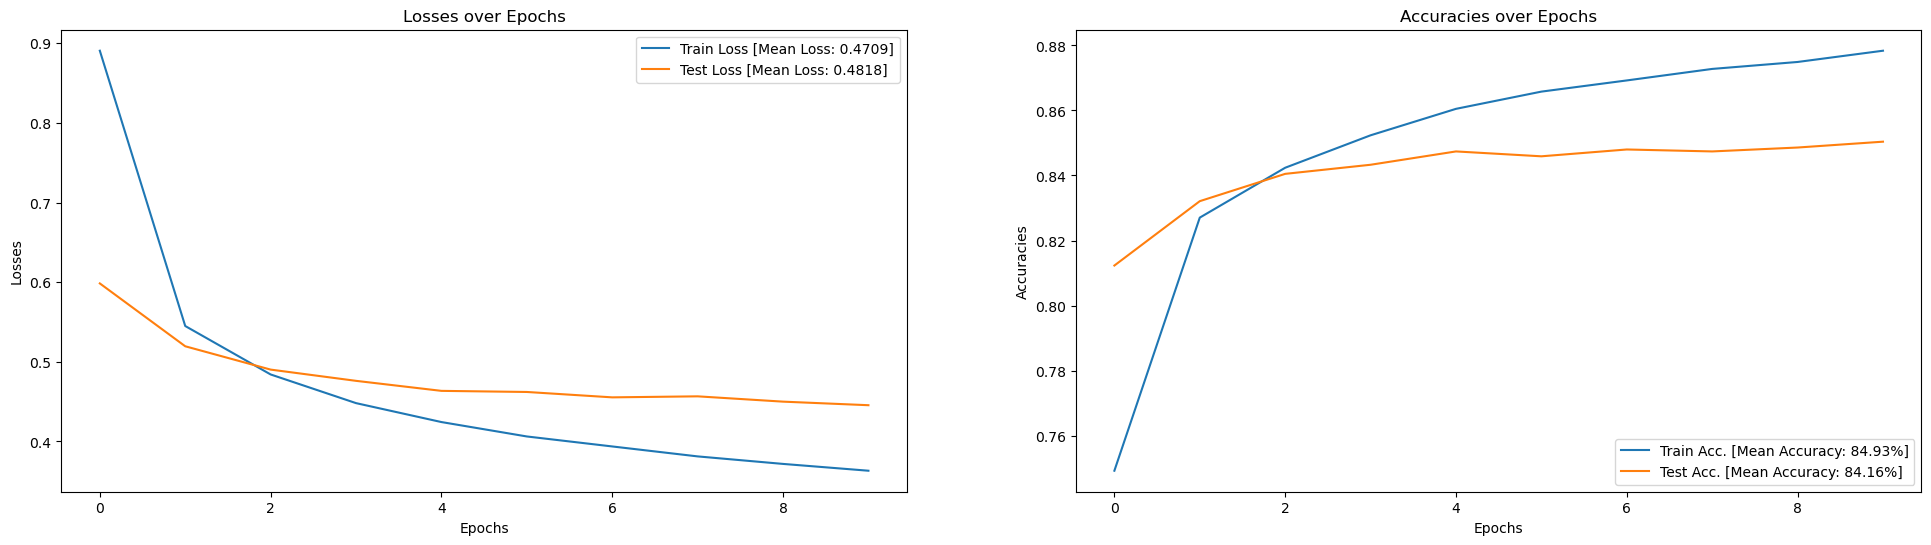

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(TRAIN_LOSSES, label=f'Train Loss [Mean Loss: {np.mean(TRAIN_LOSSES):.4f}]')
axes[0].plot(TEST_LOSSES, label=f'Test Loss [Mean Loss: {np.mean(TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(TRAIN_ACC, label=f'Train Acc. [Mean Accuracy: {(np.mean(TRAIN_ACC) * 100):.2f}%]')
axes[1].plot(TEST_ACC, label=f'Test Acc. [Mean Accuracy: {(np.mean(TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

**Why training ResNet-152 from scratch is unnecessary/impractical on small datasets**

The primary problem associated with training from scratch on small datasets is overfitting. It's because smaller datasets aren't substantial enough for ResNet-154 like big architectures to make every layer learn some useful feature. So, instead of generalization, the model starts to overfit on the dataset. Moreover, retraining whole architecture is computationally expensive and overkill for small datasets.

**What freezing most of the network tells us about transferability**

If a pretrained ResNet performs well when most layers are frozen and only the final classifier is trained, it shows that the earlier layers have learned general-purpose visual features—edges, textures, shapes, and higher-level patterns that transfer to the new dataset.

## 2. Residual Connections in Practice

### Loading ResNet152 and Removing Skip Connections

In [27]:
noskip_resnet152 = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

for name, module in noskip_resnet152.named_modules():
    print(f"{name}: {module}")

: ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1

In [28]:
class ModifiedResBlock(nn.Module):
    def __init__(self, res_module:nn.Module):
        super().__init__()
        self.conv1 = res_module.conv1
        self.bn1 = res_module.bn1
        self.conv2 = res_module.conv2
        self.bn2 = res_module.bn2
        self.conv3 = res_module.conv3
        self.bn3 = res_module.bn3
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out = self.relu(out)

        return out

In [29]:
N_CLASSES = 10
for param in noskip_resnet152.parameters():
    param.requires_grad = False

noskip_resnet152.layer1[0] = ModifiedResBlock(noskip_resnet152.layer1[0])
noskip_resnet152.layer1[0].requires_grad_(True)
noskip_resnet152.layer1[2] = ModifiedResBlock(noskip_resnet152.layer1[2])
noskip_resnet152.layer1[2].requires_grad_(True)


noskip_resnet152.layer2[0] = ModifiedResBlock(noskip_resnet152.layer2[0])
noskip_resnet152.layer2[0].requires_grad_(True)
noskip_resnet152.layer2[2] = ModifiedResBlock(noskip_resnet152.layer2[2])
noskip_resnet152.layer2[2].requires_grad_(True)
noskip_resnet152.layer2[7] = ModifiedResBlock(noskip_resnet152.layer2[7])
noskip_resnet152.layer2[7].requires_grad_(True)


noskip_resnet152.layer3[0] = ModifiedResBlock(noskip_resnet152.layer3[0])
noskip_resnet152.layer3[0].requires_grad_(True)
noskip_resnet152.layer3[5] = ModifiedResBlock(noskip_resnet152.layer3[5])
noskip_resnet152.layer3[5].requires_grad_(True)
noskip_resnet152.layer3[10] = ModifiedResBlock(noskip_resnet152.layer3[10])
noskip_resnet152.layer3[10].requires_grad_(True)
noskip_resnet152.layer3[15] = ModifiedResBlock(noskip_resnet152.layer3[15])
noskip_resnet152.layer3[15].requires_grad_(True)
noskip_resnet152.layer3[20] = ModifiedResBlock(noskip_resnet152.layer3[20])
noskip_resnet152.layer3[20].requires_grad_(True)
noskip_resnet152.layer3[25] = ModifiedResBlock(noskip_resnet152.layer3[25])
noskip_resnet152.layer3[25].requires_grad_(True)
noskip_resnet152.layer3[30] = ModifiedResBlock(noskip_resnet152.layer3[30])
noskip_resnet152.layer3[30].requires_grad_(True)
noskip_resnet152.layer3[35] = ModifiedResBlock(noskip_resnet152.layer3[35])
noskip_resnet152.layer3[35].requires_grad_(True)


noskip_resnet152.layer4[0] = ModifiedResBlock(noskip_resnet152.layer4[0])
noskip_resnet152.layer4[0].requires_grad_(True)
noskip_resnet152.layer4[2] = ModifiedResBlock(noskip_resnet152.layer4[2])
noskip_resnet152.layer4[2].requires_grad_(True)


in_features = noskip_resnet152.fc.in_features
noskip_resnet152.fc = nn.Linear(in_features, N_CLASSES)
noskip_resnet152.fc.requires_grad_(True)
noskip_resnet152.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ModifiedResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): Bottleneck(
      (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=

### Training Loop

In [11]:
EPOCHS = 10
LR = 1e-3

TRAIN_LOSSES = []
TEST_LOSSES = []
TRAIN_ACC = []
TEST_ACC = []

trainable_params = [p for p in noskip_resnet152.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable_params, lr=LR)
criterion = nn.CrossEntropyLoss()

for i in range(EPOCHS):
    train_loss, train_acc = train_epoch(noskip_resnet152, optimizer, criterion, device)
    test_loss, test_acc = evaluate(noskip_resnet152, criterion, device)

    TRAIN_LOSSES.append(train_loss)
    TEST_LOSSES.append(test_loss)
    TRAIN_ACC.append(train_acc)
    TEST_ACC.append(test_acc)

    print(f"Epoch {i + 1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc.: {(train_acc * 100):.2f}% | Test Acc.: {(test_acc * 100):.2f}%")

os.makedirs('./models', exist_ok=True)
torch.save(noskip_resnet152.state_dict(), './models/noskip_resnet152.pth')
with open('./models/noskip_resnet152_hist.pkl', 'wb') as file:
    pickle.dump({'train_loss':TRAIN_LOSSES, 'test_loss':TEST_LOSSES, 'train_acc':TRAIN_ACC,'test_acc':TEST_ACC}, file)

print('Checkpoint saved.')

100%|██████████| 157/157 [01:21<00:00,  1.92it/s]


Epoch 1 | Train Loss: 2.2935 | Test Loss: 2.4868 | Train Acc.: 11.04% | Test Acc.: 11.68%


100%|██████████| 157/157 [01:23<00:00,  1.89it/s]


Epoch 2 | Train Loss: 2.2226 | Test Loss: 12.1192 | Train Acc.: 15.80% | Test Acc.: 17.19%


100%|██████████| 157/157 [01:22<00:00,  1.90it/s]


...

Epoch 8 | Train Loss: 1.3543 | Test Loss: 1.8170 | Train Acc.: 50.52% | Test Acc.: 50.23%


100%|██████████| 157/157 [01:23<00:00,  1.87it/s]


Epoch 9 | Train Loss: 1.2196 | Test Loss: 1.6071 | Train Acc.: 55.68% | Test Acc.: 56.00%


100%|██████████| 157/157 [01:23<00:00,  1.88it/s]


Epoch 10 | Train Loss: 1.1437 | Test Loss: 1.2206 | Train Acc.: 58.47% | Test Acc.: 56.99%
Checkpoint saved.


In [30]:
TRAIN_LOSSES = []
TEST_LOSSES = []
TRAIN_ACC = []
TEST_ACC = []

chkpoint = torch.load('./models/noskip_resnet152.pth', map_location=device)
noskip_resnet152.load_state_dict(chkpoint)

with open('./models/noskip_resnet152_hist.pkl', 'rb') as file:
    data = pickle.load(file)
    TRAIN_LOSSES = data['train_loss']
    TEST_LOSSES = data['test_loss']
    TRAIN_ACC = data['train_acc']
    TEST_ACC = data['test_acc']

print("Loaded.")

C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_21520\822577550.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpoint = torch.load('./models/noskip_resnet152.pth',

Loaded.


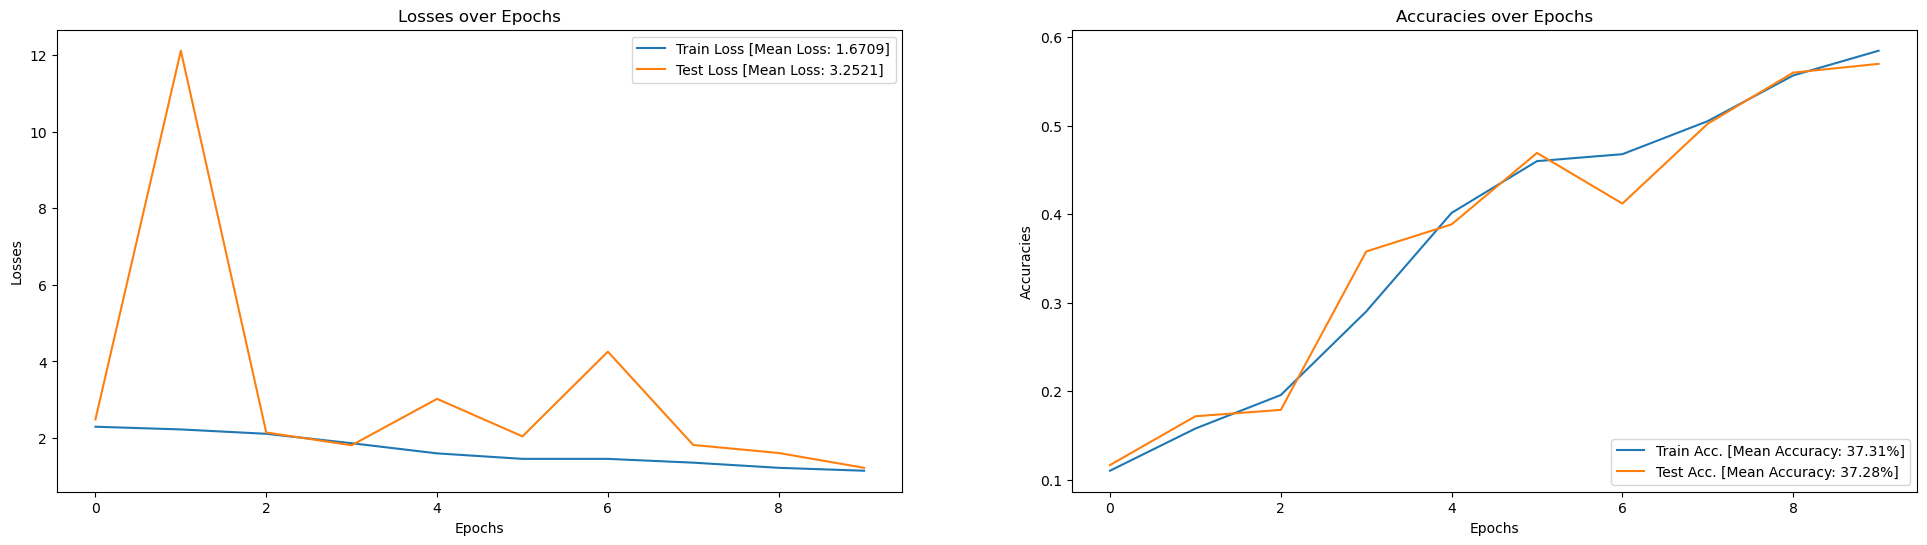

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(TRAIN_LOSSES, label=f'Train Loss [Mean Loss: {np.mean(TRAIN_LOSSES):.4f}]')
axes[0].plot(TEST_LOSSES, label=f'Test Loss [Mean Loss: {np.mean(TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(TRAIN_ACC, label=f'Train Acc. [Mean Accuracy: {(np.mean(TRAIN_ACC) * 100):.2f}%]')
axes[1].plot(TEST_ACC, label=f'Test Acc. [Mean Accuracy: {(np.mean(TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

### Comparison of Baseline and Disabled Skip Connections Models

In [35]:
BASELINE_TEST_LOSSES = []
BASELINE_TEST_ACC = []
with open('./models/baseline_resnet152_hist.pkl', 'rb') as file:
    data = pickle.load(file)
    BASELINE_TEST_LOSSES = data['test_loss']
    BASELINE_TEST_ACC = data['test_acc']

NOSKIP_TEST_LOSSES = []
NOSKIP_TEST_ACC = []
with open('./models/noskip_resnet152_hist.pkl', 'rb') as file:
    data = pickle.load(file)
    NOSKIP_TEST_LOSSES = data['test_loss']
    NOSKIP_TEST_ACC = data['test_acc']


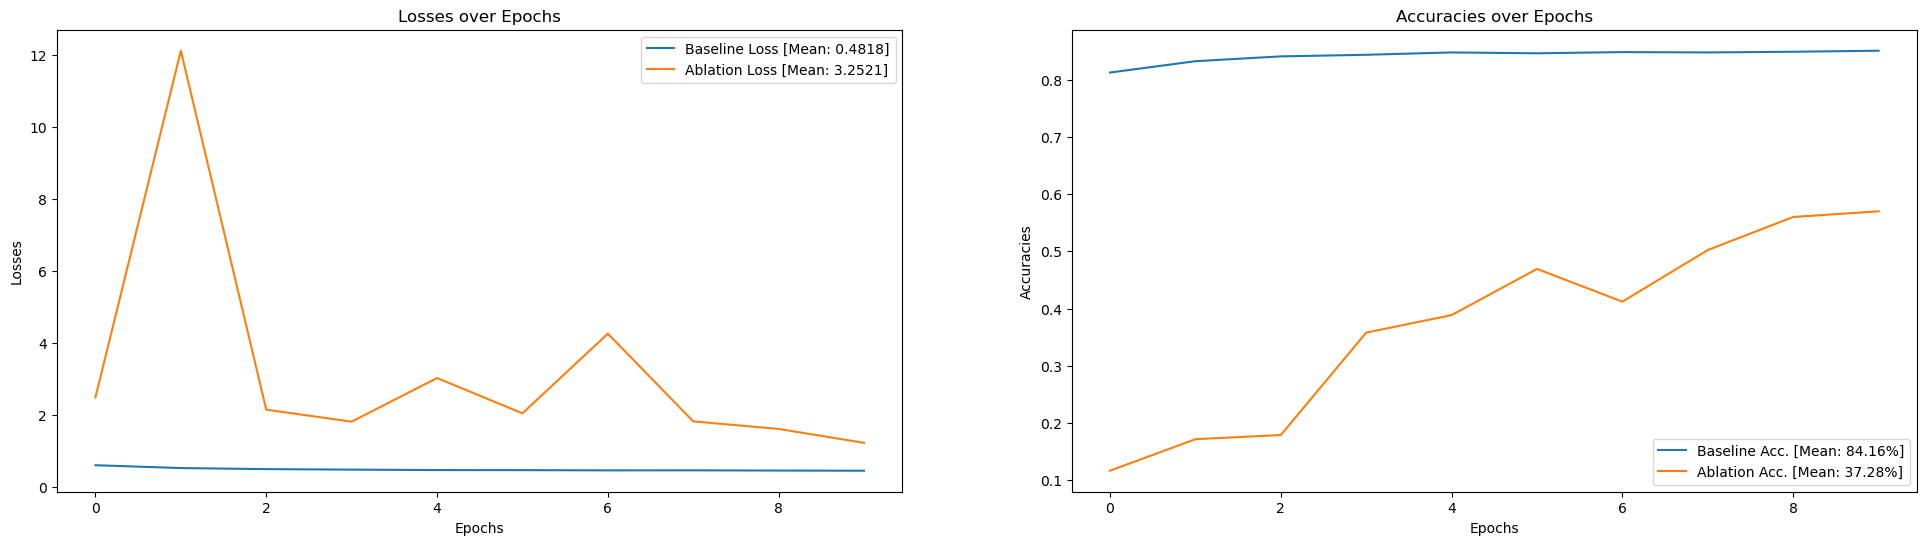

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(BASELINE_TEST_LOSSES, label=f'Baseline Loss [Mean: {np.mean(BASELINE_TEST_LOSSES):.4f}]')
axes[0].plot(NOSKIP_TEST_LOSSES, label=f'Ablation Loss [Mean: {np.mean(NOSKIP_TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(BASELINE_TEST_ACC, label=f'Baseline Acc. [Mean: {(np.mean(BASELINE_TEST_ACC) * 100):.2f}%]')
axes[1].plot(NOSKIP_TEST_ACC, label=f'Ablation Acc. [Mean: {(np.mean(NOSKIP_TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

**Comparison**

1. **Convergence Speed**: In same no. of epochs (10 Epochs), baseline model learnt quickly and converged early, while the ablation model (disabled skip connections) struggled to converge and learn smoothly. It was still learning at 10th epoch.
2. **Stability**: The gradient flow in baseline model was stable giving smooth convergence. However, in ablation model, gradient flow was unstable and gave rise to unstable training and spikes.
3. **Accuracy**: Baseline model gave more validation accuracy (84.16%) while Ablation model gave far less (37.28%) giving clear distinction.

**How do skip connections change gradient flow in very deep networks? What happens to convergence speed and
performance when residuals are removed?**

Skip connections give gradients a direct path back to earlier layers, so even in very deep networks like ResNet-152, gradients don't vanish before reaching the early layers.
When you remove them, gradients have to pass through many stacked conv-BN-ReLU layers with nothing to reinforce them, so they shrink at each layer and effectively vanish by the time they reach the front of the network.
In the results, this shows up clearly: the no-skip model converges much slower (still improving at epoch 9, no plateau), trains unstably (test loss spikes to 12+), and caps out around 37% accuracy versus the baseline's fast, stable convergence to around 84%. So removing residuals doesn't just hurt final accuracy, it makes optimization itself harder.

## 3. Visualization and Analysis of Class Separation Across Different Layers

We'll use ResNet-152 Model finetuned on CIFAR-10 dataset

### Initialization and Loading Model

In [8]:
N_CLASSES = 10
model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, N_CLASSES)
model.fc.requires_grad_(True)
model.to(device)

chkpoint = torch.load('./models/baseline_resnet152.pth', map_location=device)
model.load_state_dict(chkpoint)
print("Loaded.")

C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_27696\1328631314.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpoint = torch.load('./models/baseline_resnet152.p

Loaded.


In [9]:
for name,_ in model.named_modules():
    print(name)


conv1
bn1
relu
maxpool
layer1
layer1.0
layer1.0.conv1
layer1.0.bn1
layer1.0.conv2
layer1.0.bn2
layer1.0.conv3
layer1.0.bn3
layer1.0.relu
layer1.0.downsample
layer1.0.downsample.0
layer1.0.downsample.1
layer1.1
layer1.1.conv1
layer1.1.bn1
layer1.1.conv2
layer1.1.bn2
layer1.1.conv3
layer1.1.bn3
layer1.1.relu
layer1.2
layer1.2.conv1
layer1.2.bn1
layer1.2.conv2
layer1.2.bn2
layer1.2.conv3
layer1.2.bn3
layer1.2.relu
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.conv2
layer2.0.bn2
layer2.0.conv3
layer2.0.bn3
layer2.0.relu
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.conv2
layer2.1.bn2
layer2.1.conv3
layer2.1.bn3
layer2.1.relu
layer2.2
layer2.2.conv1
layer2.2.bn1
layer2.2.conv2
layer2.2.bn2
layer2.2.conv3
layer2.2.bn3
layer2.2.relu
layer2.3
layer2.3.conv1
layer2.3.bn1
layer2.3.conv2
layer2.3.bn2
layer2.3.conv3
layer2.3.bn3
layer2.3.relu
layer2.4
layer2.4.conv1
layer2.4.bn1
layer2.4.conv2
layer2.4.bn2
layer2.4.conv3
layer

### Registering forward hooks for selected layers

In [10]:
features = {}
hook_handles = []

def save_features(name):
    def hook(module, input, output):
        features[name] = output.detach().cpu()
    return hook


for name in ['layer1', 'layer2', 'layer3', 'layer4']:
    layer:nn.Module = getattr(model, name)
    hook = layer.register_forward_hook(save_features(name))
    hook_handles.append(hook)

### Inference

In [11]:
model.eval()

feature_chunks = {layer: [] for layer in ['layer1', 'layer2', 'layer3', 'layer4']}
label_chunks = []

max_total = 3000
seen = 0

with torch.no_grad():
    for imgs, lbls in tqdm(cifar10_testloader, desc="Evaluating"):
        imgs = imgs.to(device)
        output = model(imgs)

        for layer in feature_chunks:
            pooled = features[layer].mean(dim=(2, 3))
            feature_chunks[layer].append(pooled)

        label_chunks.append(lbls)

        del output
        torch.cuda.empty_cache()

        seen += imgs.size(0)
        if seen >= max_total:
            break

features_all = {layer: torch.cat(chunks, dim=0) for layer, chunks in feature_chunks.items()}
labels_all = torch.cat(label_chunks, dim=0)

Evaluating:  29%|██▉       | 46/157 [00:26<01:04,  1.71it/s]


### Heatmap visualization of layers

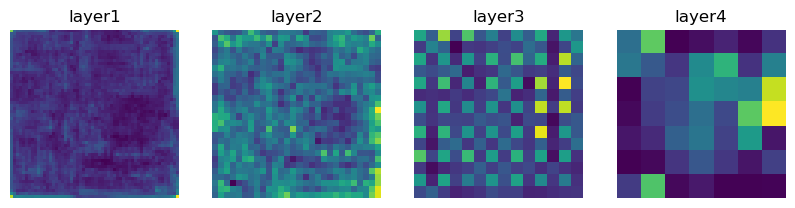

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(10, 10))
for i, layer in enumerate(['layer1', 'layer2', 'layer3', 'layer4']):
    feature = features[layer]

    sample = feature[0]
    sample = sample.mean(dim=0).numpy()

    axes[i].imshow(sample)
    axes[i].axis('off')
    axes[i].set_title(layer)

### UMAP Visualization

Processing Layer:   0%|          | 0/4 [00:00<?, ?it/s]c:\Users\Syed Daniyal\.conda\envs\torch_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


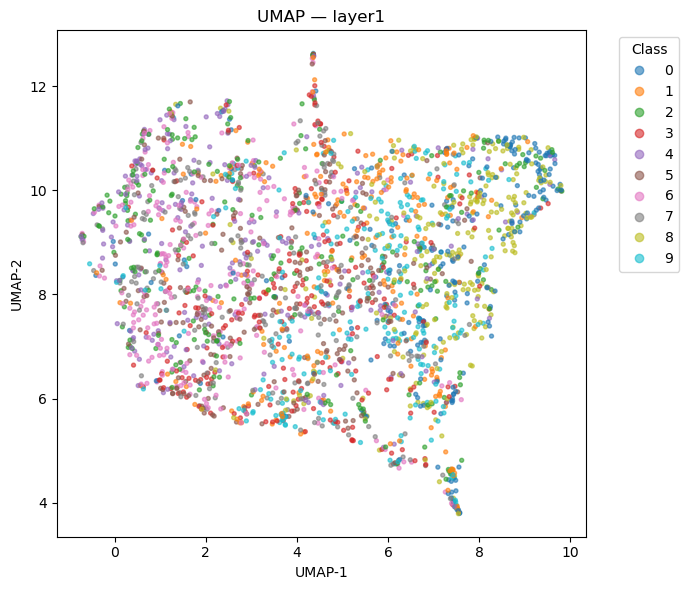

Processing Layer:  25%|██▌       | 1/4 [00:17<00:51, 17.16s/it]c:\Users\Syed Daniyal\.conda\envs\torch_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


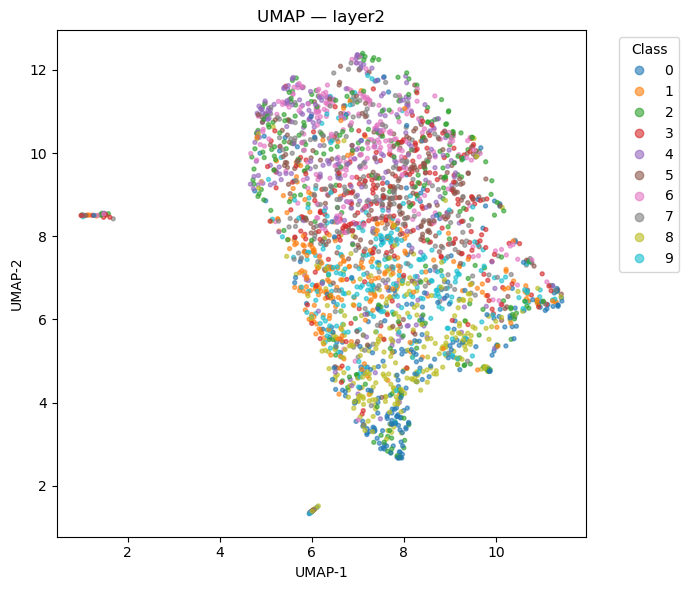

Processing Layer:  50%|█████     | 2/4 [00:25<00:24, 12.11s/it]c:\Users\Syed Daniyal\.conda\envs\torch_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


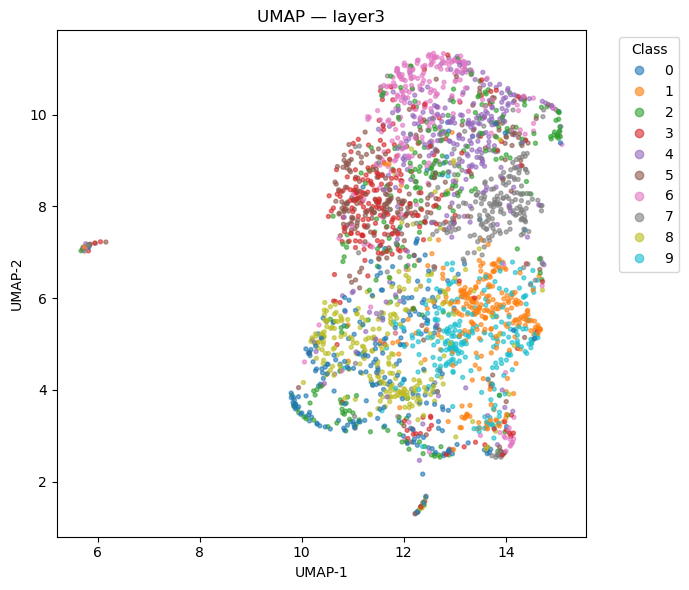

Processing Layer:  75%|███████▌  | 3/4 [00:36<00:11, 11.65s/it]c:\Users\Syed Daniyal\.conda\envs\torch_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


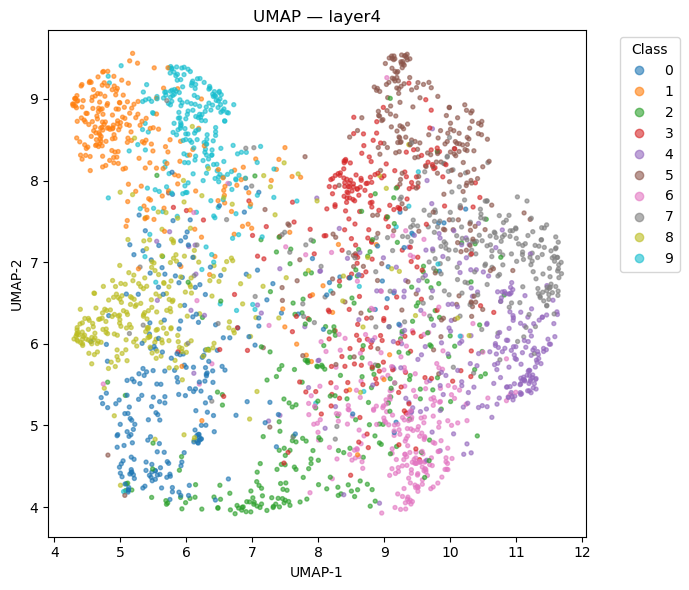

Processing Layer: 100%|██████████| 4/4 [00:50<00:00, 12.53s/it]


In [14]:
import umap.umap_ as umap

layers = ['layer1', 'layer2', 'layer3', 'layer4']

for layer in tqdm(layers, desc="Processing Layer: "):
    feature = features_all[layer]
    feature = feature.to(device)

    feature_vec = feature
    max_points = 2500
    if feature_vec.shape[0] > max_points:
        idx = torch.randperm(feature_vec.shape[0])[:max_points]
        feature_vec = feature_vec[idx]
        labels_sub = labels_all[idx]
    else:
        labels_sub = labels_all

    feature_vec = feature_vec.detach().cpu().numpy()
    labels_sub = labels_sub.detach().cpu().numpy()

    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    embedding = reducer.fit_transform(feature_vec)

    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels_sub, cmap='tab10', s=8, alpha=0.6)
    plt.title(f'UMAP — {layer}')
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')
    plt.legend(*scatter.legend_elements(), title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### Analysis

**How does class separability evolve across layers? What differences can you observe between low-level and high-
level representations?**

So, based on visualization, **class separability increases monotonically with depth.**

**Layer1:** Classes are almost completely intermixed like a one large blob with all 10 colors scattered throughout, no visible grouping. Low-level features (edges, textures, colors) are shared across classes and carry little class-specific signal.

**Layer2:** Still heavily mixed, but faint local trends start to emerge. Marginal improvement over layer1.

**Layer3:** Clearer regional organization and distinct zones start forming, though boundaries are still blurry and classes overlap significantly at zone edges.

**Layer4:** Sharpest separation by far since most classes now occupy distinct, mostly non-overlapping regions, but the class structure is now clearly visible in 2D.

Early layers (1–2) encode generic, low-level visual features that are largely class-agnostic, so embeddings show heavy inter-class mixing. Deeper layers (3–4) encode increasingly abstract, semantic features, producing progressively tighter and better-separated class clusters which is consistent with how CNNs build hierarchical representations, with the final layers being most discriminative for classification. The same thing can be observed in earlier heatmap visualization that initial layers represent low level features while as we move on it starts to represent high level abstract features

## 4. Transfer Learning and Generalization

### a) Fine-tuning Model on Dataset other than ImageNet: CIFAR-10

We need three ResNet-152 variants for analysis and experiment:

1. ResNet-152 (Pre-trained ImageNetV2) Fine-tuned Head Only with CIFAR-10
2. ResNet-152 (Pre-trained ImageNetV2) Fine-tuned whole Backbone with CIFAR-10
3. ResNet-152 Scratch Training on CIFAR-10 (Random Initialization)

### Variant 1: ResNet-152 (Pre-trained ImageNetV2) Fine-tuned Head Only with CIFAR-10

Since we already did training for this version in the start of notebook as baseline. We'll load it directly

In [8]:
N_CLASSES = 10
head_finetuned_resnet = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

for param in head_finetuned_resnet.parameters():
    param.requires_grad = False

in_features = head_finetuned_resnet.fc.in_features
head_finetuned_resnet.fc = nn.Linear(in_features, N_CLASSES)
head_finetuned_resnet.fc.requires_grad_(True)
head_finetuned_resnet.to(device)

chkpoint = torch.load('./models/baseline_resnet152.pth', map_location=device)
head_finetuned_resnet.load_state_dict(chkpoint)

HEAD_FINETUNED_TRAIN_LOSSES = []
HEAD_FINETUNED_TEST_LOSSES = []
HEAD_FINETUNED_TRAIN_ACC = []
HEAD_FINETUNED_TEST_ACC = []

with open('./models/baseline_resnet152_hist.pkl', 'rb') as file:
    data = pickle.load(file)
    HEAD_FINETUNED_TRAIN_LOSSES = data['train_loss']
    HEAD_FINETUNED_TEST_LOSSES = data['test_loss']
    HEAD_FINETUNED_TRAIN_ACC = data['train_acc']
    HEAD_FINETUNED_TEST_ACC = data['test_acc']

print("Loaded.")

C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_14360\3035625866.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpoint = torch.load('./models/baseline_resnet152.p

Loaded.


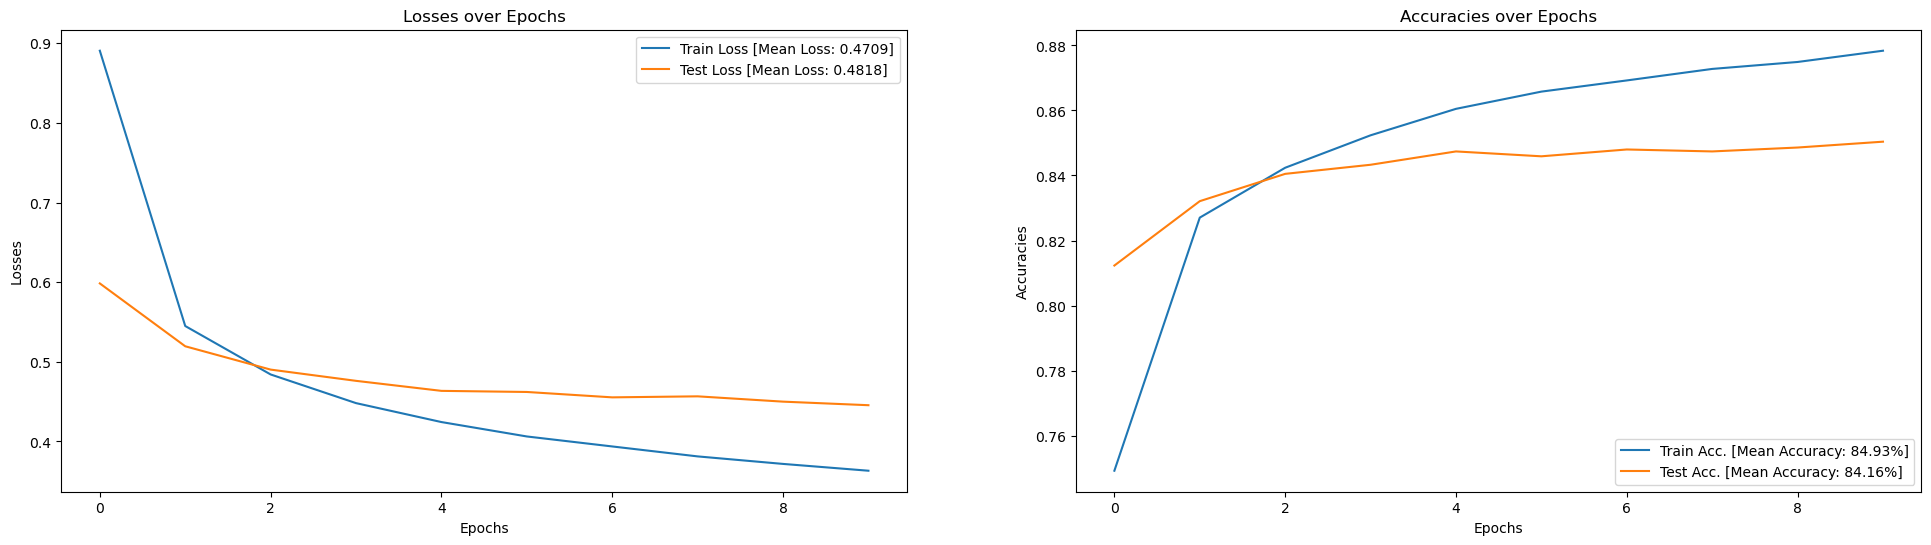

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(HEAD_FINETUNED_TRAIN_LOSSES, label=f'Train Loss [Mean Loss: {np.mean(HEAD_FINETUNED_TRAIN_LOSSES):.4f}]')
axes[0].plot(HEAD_FINETUNED_TEST_LOSSES, label=f'Test Loss [Mean Loss: {np.mean(HEAD_FINETUNED_TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(HEAD_FINETUNED_TRAIN_ACC, label=f'Train Acc. [Mean Accuracy: {(np.mean(HEAD_FINETUNED_TRAIN_ACC) * 100):.2f}%]')
axes[1].plot(HEAD_FINETUNED_TEST_ACC, label=f'Test Acc. [Mean Accuracy: {(np.mean(HEAD_FINETUNED_TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

### Variant 2: ResNet-152 (Pre-trained ImageNetV2) Fine-tuned Whole Backbone with CIFAR-10

In [10]:
N_CLASSES = 10
full_finetuned_resnet = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

in_features = full_finetuned_resnet.fc.in_features
full_finetuned_resnet.fc = nn.Linear(in_features, N_CLASSES)
full_finetuned_resnet.to(device)

cifar10_trainloader = DataLoader(cifar10_trainset, batch_size=64, shuffle=True)
cifar10_testloader = DataLoader(cifar10_testset, batch_size=64, shuffle=False)

In [13]:
EPOCHS = 5
LR = 1e-4

TRAIN_LOSSES = []
TEST_LOSSES = []
TRAIN_ACC = []
TEST_ACC = []

optimizer = torch.optim.Adam(full_finetuned_resnet.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
os.makedirs('./models', exist_ok=True)
for i in range(EPOCHS):
    train_loss, train_acc = train_epoch(full_finetuned_resnet, optimizer, criterion, device)
    test_loss, test_acc = evaluate(full_finetuned_resnet, criterion, device)

    TRAIN_LOSSES.append(train_loss)
    TEST_LOSSES.append(test_loss)
    TRAIN_ACC.append(train_acc)
    TEST_ACC.append(test_acc)
    
    torch.save(full_finetuned_resnet.state_dict(), './models/full_finetuned_resnet.pth')
    with open('./models/full_finetuned_resnet_hist.pkl', 'wb') as file:
        pickle.dump({'train_loss':TRAIN_LOSSES, 'test_loss':TEST_LOSSES, 'train_acc':TRAIN_ACC,'test_acc':TEST_ACC}, file)

    print(f"Epoch {i + 1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc.: {(train_acc * 100):.2f}% | Test Acc.: {(test_acc * 100):.2f}%")

torch.save(full_finetuned_resnet.state_dict(), './models/full_finetuned_resnet.pth')
with open('./models/full_finetuned_resnet_hist.pkl', 'wb') as file:
    pickle.dump({'train_loss':TRAIN_LOSSES, 'test_loss':TEST_LOSSES, 'train_acc':TRAIN_ACC,'test_acc':TEST_ACC}, file)

print('Checkpoint saved.')

100%|██████████| 157/157 [01:22<00:00,  1.91it/s]


Epoch 1 | Train Loss: 0.2436 | Test Loss: 0.0899 | Train Acc.: 92.74% | Test Acc.: 96.86%


100%|██████████| 157/157 [01:22<00:00,  1.91it/s]


Epoch 2 | Train Loss: 0.0505 | Test Loss: 0.1063 | Train Acc.: 98.39% | Test Acc.: 96.62%


100%|██████████| 157/157 [01:21<00:00,  1.92it/s]


Epoch 3 | Train Loss: 0.0356 | Test Loss: 0.1035 | Train Acc.: 98.77% | Test Acc.: 97.06%


100%|██████████| 157/157 [01:22<00:00,  1.91it/s]


Epoch 4 | Train Loss: 0.0278 | Test Loss: 0.1100 | Train Acc.: 99.06% | Test Acc.: 96.83%


100%|██████████| 157/157 [01:22<00:00,  1.91it/s]


Epoch 5 | Train Loss: 0.0240 | Test Loss: 0.1345 | Train Acc.: 99.17% | Test Acc.: 95.90%
Checkpoint saved.


In [11]:
chkpoint = torch.load('./models/full_finetuned_resnet.pth', map_location=device)
full_finetuned_resnet.load_state_dict(chkpoint)

FULL_FINETUNED_TRAIN_LOSSES = []
FULL_FINETUNED_TEST_LOSSES = []
FULL_FINETUNED_TRAIN_ACC = []
FULL_FINETUNED_TEST_ACC = []

with open('./models/full_finetuned_resnet_hist.pkl', 'rb') as file:
    data = pickle.load(file)
    FULL_FINETUNED_TRAIN_LOSSES = data['train_loss']
    FULL_FINETUNED_TEST_LOSSES = data['test_loss']
    FULL_FINETUNED_TRAIN_ACC = data['train_acc']
    FULL_FINETUNED_TEST_ACC = data['test_acc']

print("Loaded.")

C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_14360\1989861697.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpoint = torch.load('./models/full_finetuned_resnet

Loaded.


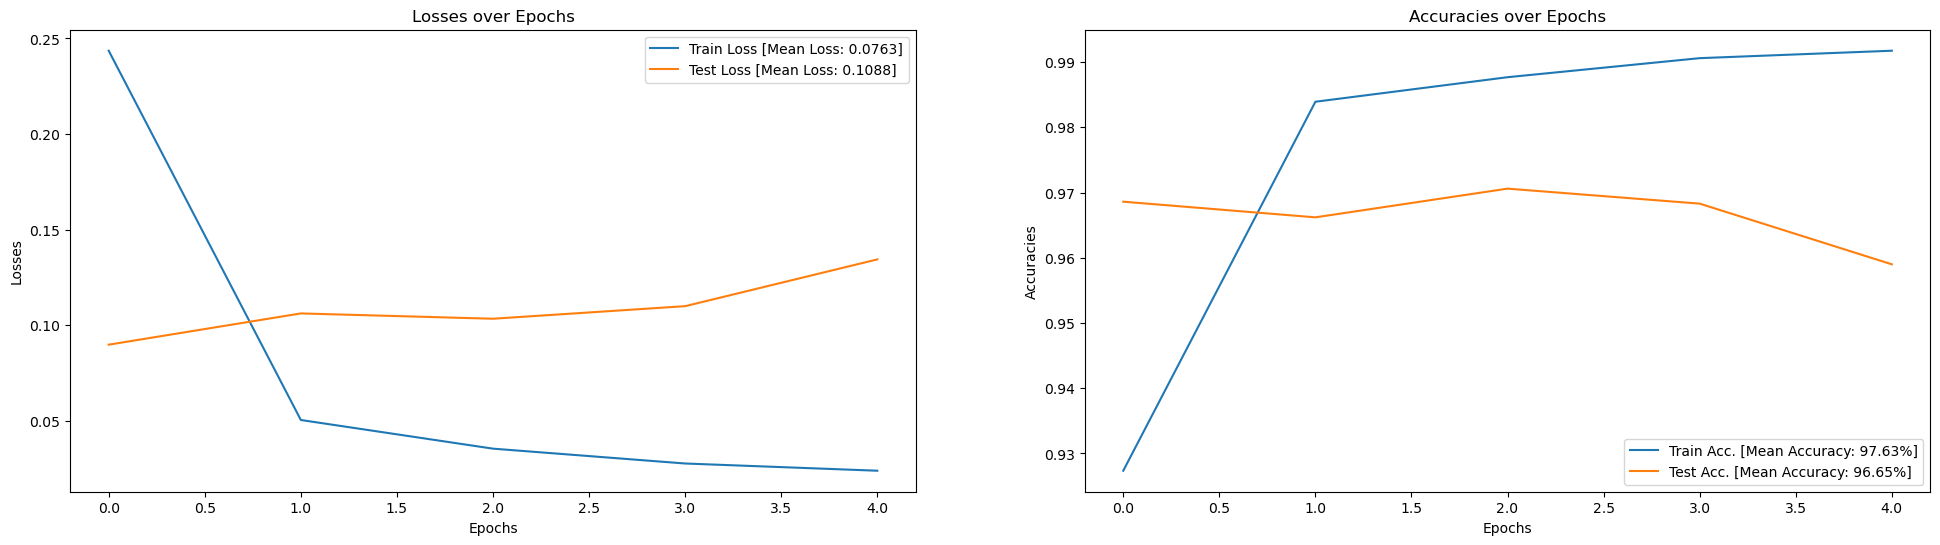

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(FULL_FINETUNED_TRAIN_LOSSES, label=f'Train Loss [Mean Loss: {np.mean(FULL_FINETUNED_TRAIN_LOSSES):.4f}]')
axes[0].plot(FULL_FINETUNED_TEST_LOSSES, label=f'Test Loss [Mean Loss: {np.mean(FULL_FINETUNED_TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(FULL_FINETUNED_TRAIN_ACC, label=f'Train Acc. [Mean Accuracy: {(np.mean(FULL_FINETUNED_TRAIN_ACC) * 100):.2f}%]')
axes[1].plot(FULL_FINETUNED_TEST_ACC, label=f'Test Acc. [Mean Accuracy: {(np.mean(FULL_FINETUNED_TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

### Variant 3: ResNet-152 Scratch Training on CIFAR-10 (Random Initialization)

In [13]:
N_CLASSES = 10
scratchtrained_resnet = models.resnet152()

in_features = scratchtrained_resnet.fc.in_features
scratchtrained_resnet.fc = nn.Linear(in_features, N_CLASSES)
scratchtrained_resnet.to(device)

cifar10_trainloader = DataLoader(cifar10_trainset, batch_size=64, shuffle=True)
cifar10_testloader = DataLoader(cifar10_testset, batch_size=64, shuffle=False)

In [ ]:
EPOCHS = 5
LR = 1e-3

TRAIN_LOSSES = []
TEST_LOSSES = []
TRAIN_ACC = []
TEST_ACC = []

optimizer = torch.optim.Adam(scratchtrained_resnet.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
os.makedirs('./models', exist_ok=True)
for i in range(EPOCHS):
    train_loss, train_acc = train_epoch(scratchtrained_resnet, optimizer, criterion, device)
    test_loss, test_acc = evaluate(scratchtrained_resnet, criterion, device)

    TRAIN_LOSSES.append(train_loss)
    TEST_LOSSES.append(test_loss)
    TRAIN_ACC.append(train_acc)
    TEST_ACC.append(test_acc)
    
    torch.save(scratchtrained_resnet.state_dict(), './models/scratchtrained_resnet.pth')
    with open('./models/scratchtrained_resnet_hist.pkl', 'wb') as file:
        pickle.dump({'train_loss':TRAIN_LOSSES, 'test_loss':TEST_LOSSES, 'train_acc':TRAIN_ACC,'test_acc':TEST_ACC}, file)

    print(f"Epoch {i + 1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc.: {(train_acc * 100):.2f}% | Test Acc.: {(test_acc * 100):.2f}%")

torch.save(scratchtrained_resnet.state_dict(), './models/scratchtrained_resnet.pth')
with open('./models/scratchtrained_resnet_hist.pkl', 'wb') as file:
    pickle.dump({'train_loss':TRAIN_LOSSES, 'test_loss':TEST_LOSSES, 'train_acc':TRAIN_ACC,'test_acc':TEST_ACC}, file)

print('Checkpoint saved.')

100%|██████████| 157/157 [01:31<00:00,  1.71it/s]


Epoch 1 | Train Loss: 1.7881 | Test Loss: 1.8001 | Train Acc.: 33.02% | Test Acc.: 35.93%


100%|██████████| 157/157 [01:31<00:00,  1.71it/s]


Epoch 2 | Train Loss: 1.3540 | Test Loss: 1.4170 | Train Acc.: 50.22% | Test Acc.: 51.92%


100%|██████████| 157/157 [01:31<00:00,  1.71it/s]


Epoch 3 | Train Loss: 1.0102 | Test Loss: 0.9124 | Train Acc.: 63.86% | Test Acc.: 67.86%


100%|██████████| 157/157 [01:31<00:00,  1.71it/s]


Epoch 4 | Train Loss: 0.7905 | Test Loss: 0.8895 | Train Acc.: 72.13% | Test Acc.: 68.66%


 57%|█████▋    | 446/782 [12:46<09:39,  1.73s/it]

In [10]:
chkpoint = torch.load('./models/scratchtrained_resnet.pth', map_location=device)
scratchtrained_resnet.load_state_dict(chkpoint)
print("4 Epochs already trained, continuing from last epoch: ")

EPOCHS = 1
LR = 1e-3

TRAIN_LOSSES = []
TEST_LOSSES = []
TRAIN_ACC = []
TEST_ACC = []

optimizer = torch.optim.Adam(scratchtrained_resnet.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
os.makedirs('./models', exist_ok=True)
for i in range(EPOCHS):
    train_loss, train_acc = train_epoch(scratchtrained_resnet, optimizer, criterion, device)
    test_loss, test_acc = evaluate(scratchtrained_resnet, criterion, device)

    TRAIN_LOSSES.append(train_loss)
    TEST_LOSSES.append(test_loss)
    TRAIN_ACC.append(train_acc)
    TEST_ACC.append(test_acc)
    
    torch.save(scratchtrained_resnet.state_dict(), './models/scratchtrained_resnet.pth')
    with open('./models/scratchtrained_resnet_hist.pkl', 'wb') as file:
        pickle.dump({'train_loss':TRAIN_LOSSES, 'test_loss':TEST_LOSSES, 'train_acc':TRAIN_ACC,'test_acc':TEST_ACC}, file)

    print(f"Epoch {i + 4} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc.: {(train_acc * 100):.2f}% | Test Acc.: {(test_acc * 100):.2f}%")

torch.save(scratchtrained_resnet.state_dict(), './models/scratchtrained_resnet.pth')
with open('./models/scratchtrained_resnet_hist.pkl', 'wb') as file:
    pickle.dump({'train_loss':TRAIN_LOSSES, 'test_loss':TEST_LOSSES, 'train_acc':TRAIN_ACC,'test_acc':TEST_ACC}, file)

print('Checkpoint saved.')

4 Epochs already trained, continuing from last epoch: 


100%|██████████| 157/157 [01:29<00:00,  1.75it/s]


Epoch 4 | Train Loss: 0.7296 | Test Loss: 0.7448 | Train Acc.: 74.60% | Test Acc.: 73.96%
Checkpoint saved.


In [14]:
chkpoint = torch.load('./models/scratchtrained_resnet.pth', map_location=device)
scratchtrained_resnet.load_state_dict(chkpoint)

SCRATCHTRAINED_TRAIN_LOSSES = []
SCRATCHTRAINED_TEST_LOSSES = []
SCRATCHTRAINED_TRAIN_ACC = []
SCRATCHTRAINED_TEST_ACC = []

with open('./models/scratchtrained_resnet_hist.pkl', 'rb') as file:
    data = pickle.load(file)
    SCRATCHTRAINED_TRAIN_LOSSES = data['train_loss']
    SCRATCHTRAINED_TEST_LOSSES = data['test_loss']
    SCRATCHTRAINED_TRAIN_ACC = data['train_acc']
    SCRATCHTRAINED_TEST_ACC = data['test_acc']

print("Loaded.")

C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_14360\1458274406.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpoint = torch.load('./models/scratchtrained_resnet

Loaded.


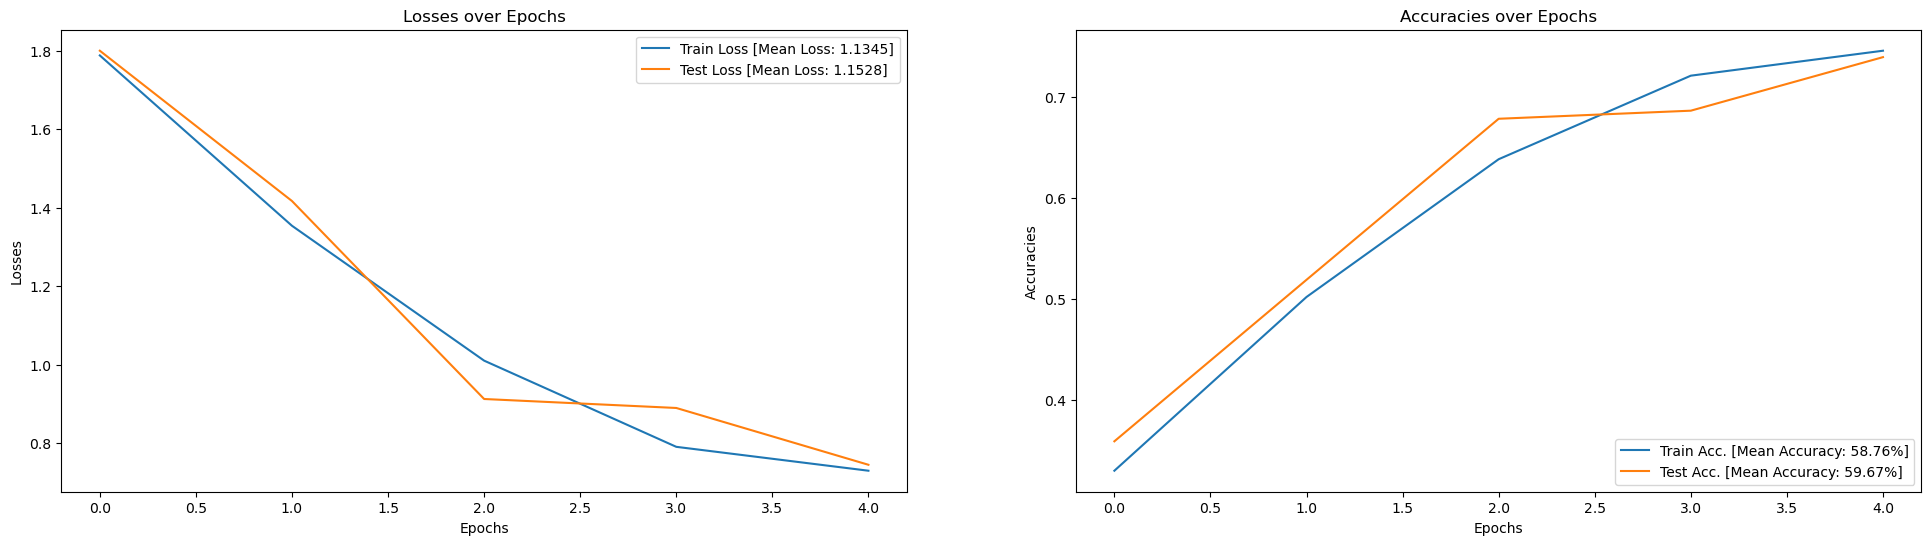

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(SCRATCHTRAINED_TRAIN_LOSSES, label=f'Train Loss [Mean Loss: {np.mean(SCRATCHTRAINED_TRAIN_LOSSES):.4f}]')
axes[0].plot(SCRATCHTRAINED_TEST_LOSSES, label=f'Test Loss [Mean Loss: {np.mean(SCRATCHTRAINED_TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(SCRATCHTRAINED_TRAIN_ACC, label=f'Train Acc. [Mean Accuracy: {(np.mean(SCRATCHTRAINED_TRAIN_ACC) * 100):.2f}%]')
axes[1].plot(SCRATCHTRAINED_TEST_ACC, label=f'Test Acc. [Mean Accuracy: {(np.mean(SCRATCHTRAINED_TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

### Comparison of performance of Head-only fine-tuned  ImageNet weights vs. Random initialization

In [22]:
def get_parameters(model):
    return sum(p.numel() for p in model.parameters())

def get_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [31]:
paramA = get_parameters(head_finetuned_resnet)
paramTrA = get_trainable_parameters(head_finetuned_resnet)
paramA_reduction = (paramA - paramTrA) / paramA

paramB = get_parameters(scratchtrained_resnet)
paramTrB = get_trainable_parameters(scratchtrained_resnet)
paramB_reduction = (paramB - paramTrB) / paramB

In [40]:
print("Comparison of ResNet (Fine-tuned Head only) vs. ResNet (Random Init): ".upper())
print("-----------------------------------------------------------------------------")
print('ResNet (Head only Fine-tuned):\n'.upper())
print("Parameters: ", paramA)
print("Trainable Parameters: ", paramTrA)
print(f"Parameters Reduction: {(paramA_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(HEAD_FINETUNED_TEST_ACC) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 39 min approx.")

print("-----------------------------------------------------------------------------")
print('ResNet (Random Init):\n'.upper())
print("Parameters: ", paramB)
print("Trainable Parameters: ", paramTrB)
print(f"Parameters Reduction: {(paramB_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(SCRATCHTRAINED_TEST_ACC) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 2 hours approx.")

COMPARISON OF RESNET (FINE-TUNED HEAD ONLY) VS. RESNET (RANDOM INIT): 
-----------------------------------------------------------------------------
RESNET (HEAD ONLY FINE-TUNED):

Parameters:  58164298
Trainable Parameters:  20490
Parameters Reduction: 99.96%
Epochs: 5
Validation Accuracy: 84.16%
Training Time (avg. observed from logs): 39 min approx.
-----------------------------------------------------------------------------
RESNET (RANDOM INIT):

Parameters:  58164298
Trainable Parameters:  58164298
Parameters Reduction: 0.00%
Epochs: 5
Validation Accuracy: 59.67%
Training Time (avg. observed from logs): 2 hours approx.


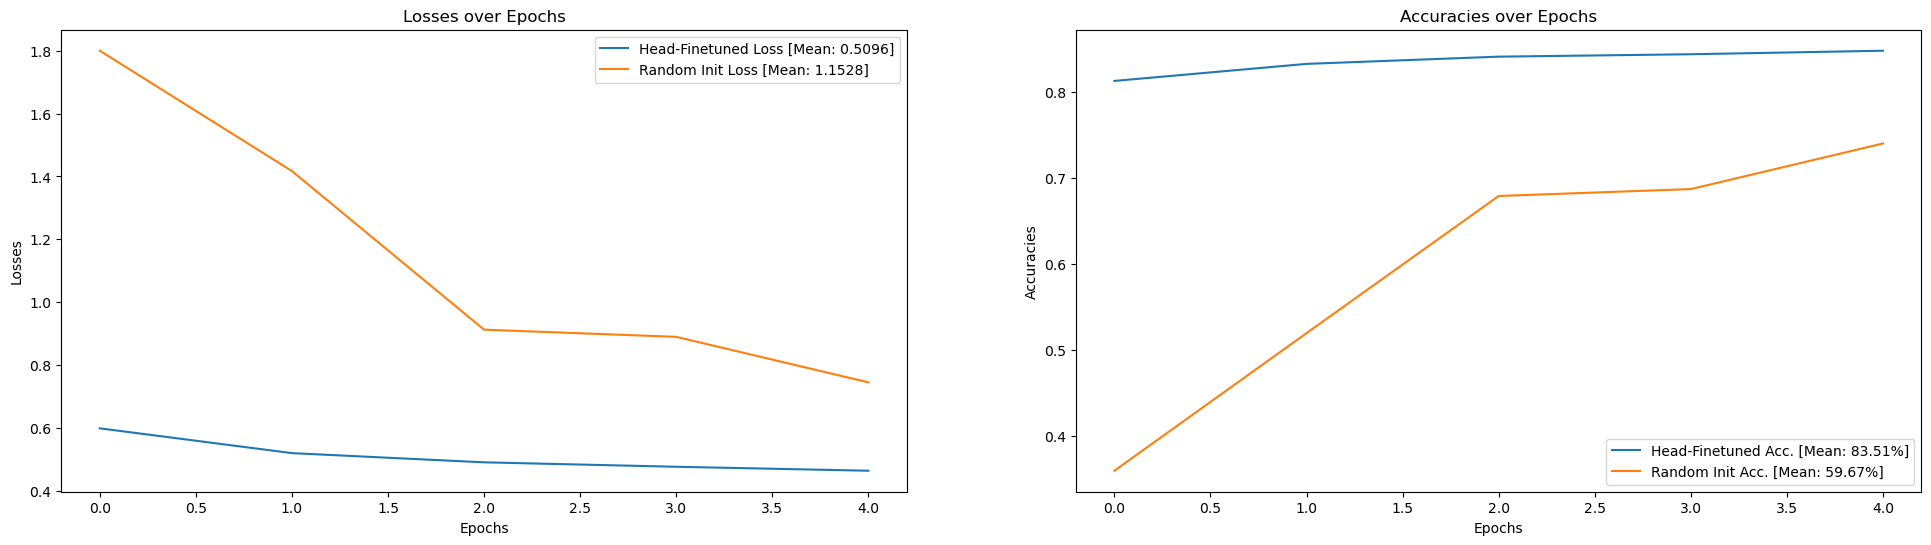

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(HEAD_FINETUNED_TEST_LOSSES[:5], label=f'Head-Finetuned Loss [Mean: {np.mean(HEAD_FINETUNED_TEST_LOSSES[:5]):.4f}]')
axes[0].plot(SCRATCHTRAINED_TEST_LOSSES, label=f'Random Init Loss [Mean: {np.mean(SCRATCHTRAINED_TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(HEAD_FINETUNED_TEST_ACC[:5], label=f'Head-Finetuned Acc. [Mean: {(np.mean(HEAD_FINETUNED_TEST_ACC[:5]) * 100):.2f}%]')
axes[1].plot(SCRATCHTRAINED_TEST_ACC, label=f'Random Init Acc. [Mean: {(np.mean(SCRATCHTRAINED_TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

**Analysis:**

Fine-tuning just the head trains 0.04% of parameters yet reaches 84.16% validation accuracy, beating random init's 59.67% by nearly 25 points despite both using identical architecture and epoch count.

This gap shows the value of pretrained ImageNet features: the frozen backbone already encodes useful low- and mid-level visual representations, so only the classifier needs to adapt to the new task.

Random init has to learn everything from scratch, including basic edge and texture detectors, which explains both the lower accuracy and the roughly 3x longer training time (2 hours vs. 39 min) since gradients flow through and update all 58M parameters each step.

In these 5 epochs, model is still underfit, i.e., it also needs more epochs to train and get performance comparable to the fine-tuned model.

The loss and accuracy curves reinforce this: the head-finetuned model starts near its final accuracy (~82%) and converges quickly, with loss flattening after epoch 2, while random init starts from a much higher loss (~1.8) and a lower accuracy (~35%), improving steadily but never catching up within the given epochs. The steeper, still-declining trajectory of random init's loss curve at epoch 4 suggests it hasn't plateaued yet and further training could still help.

Transfer learning gives a large accuracy and efficiency, both in compute and training time because the pretrained weights already encode huge portion of primary low level features, and CIFAR-10 is smaller dataset which is much easier for model to adapt.

### Comparison of performance of Head-only Fine-tuned vs. Full-Backbone Fine-tuned vs. Random Initialization

In [43]:
paramC = get_parameters(full_finetuned_resnet)
paramTrC = get_trainable_parameters(full_finetuned_resnet)
paramC_reduction = (paramC - paramTrC) / paramC

In [44]:
print("Comparison of ResNet (Fine-tuned Head only) vs. ResNet (Full Backbone Fine-tuned): ".upper())
print("-----------------------------------------------------------------------------")
print('ResNet (Head only Fine-tuned):\n'.upper())
print("Parameters: ", paramA)
print("Trainable Parameters: ", paramTrA)
print(f"Parameters Reduction: {(paramA_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(HEAD_FINETUNED_TEST_ACC[:5]) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 39 min approx.")

print("-----------------------------------------------------------------------------")
print('ResNet (Full Backbone Fine-tuned):\n'.upper())
print("Parameters: ", paramC)
print("Trainable Parameters: ", paramTrC)
print(f"Parameters Reduction: {(paramC_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(FULL_FINETUNED_TEST_ACC) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 1 hour 43 min approx.")

COMPARISON OF RESNET (FINE-TUNED HEAD ONLY) VS. RESNET (FULL BACKBONE FINE-TUNED): 
-----------------------------------------------------------------------------
RESNET (HEAD ONLY FINE-TUNED):

Parameters:  58164298
Trainable Parameters:  20490
Parameters Reduction: 99.96%
Epochs: 5
Validation Accuracy: 83.51%
Training Time (avg. observed from logs): 39 min approx.
-----------------------------------------------------------------------------
RESNET (FULL BACKBONE FINE-TUNED):

Parameters:  58164298
Trainable Parameters:  58164298
Parameters Reduction: 0.00%
Epochs: 5
Validation Accuracy: 96.65%
Training Time (avg. observed from logs): 1 hour 43 min approx.


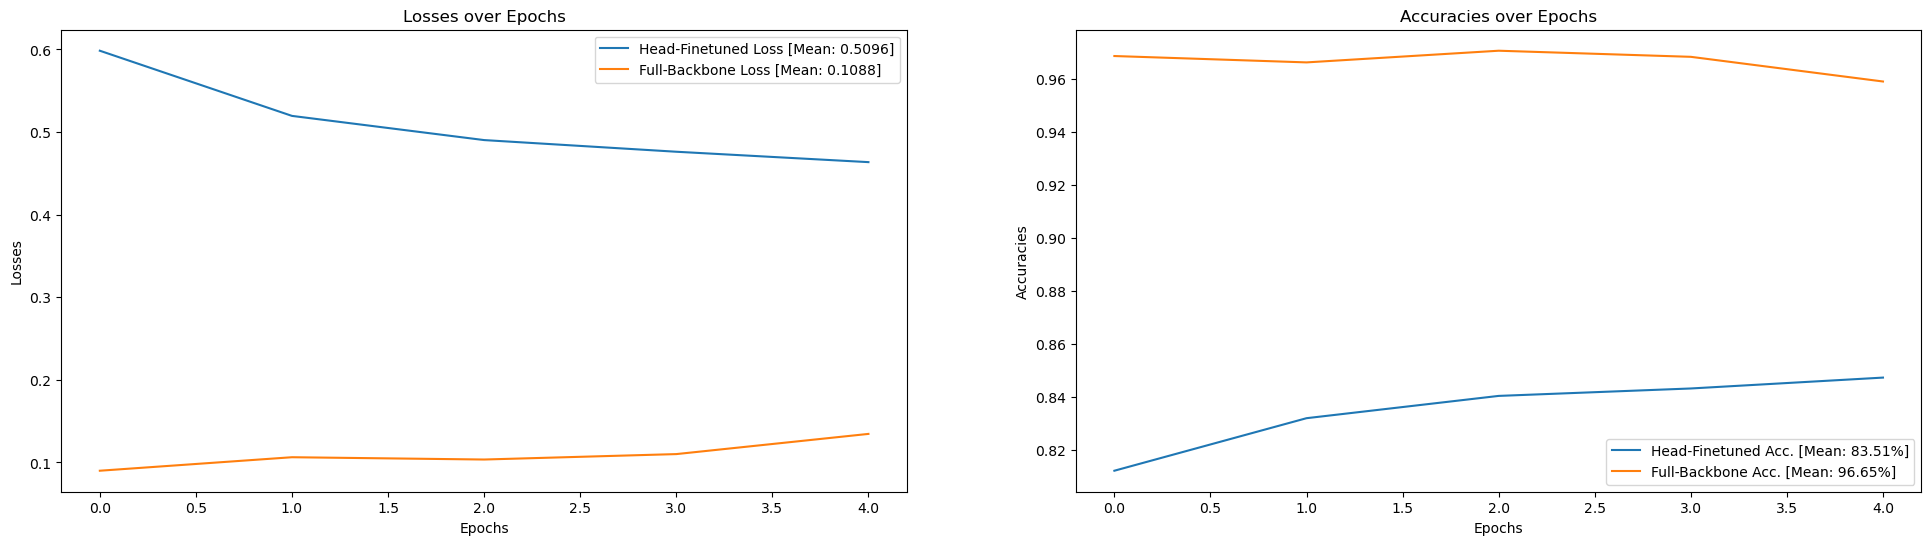

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(HEAD_FINETUNED_TEST_LOSSES[:5], label=f'Head-Finetuned Loss [Mean: {np.mean(HEAD_FINETUNED_TEST_LOSSES[:5]):.4f}]')
axes[0].plot(FULL_FINETUNED_TEST_LOSSES, label=f'Full-Backbone Loss [Mean: {np.mean(FULL_FINETUNED_TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(HEAD_FINETUNED_TEST_ACC[:5], label=f'Head-Finetuned Acc. [Mean: {(np.mean(HEAD_FINETUNED_TEST_ACC[:5]) * 100):.2f}%]')
axes[1].plot(FULL_FINETUNED_TEST_ACC, label=f'Full-Backbone Acc. [Mean: {(np.mean(FULL_FINETUNED_TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

**Analysis:**

Full-backbone fine-tuning updates all 58M parameters (0 percent reduction) versus just 20,490 for head-only (99.96 percent reduction), yet the extra capacity pays off here: full-backbone reaches roughly 96 percent validation accuracy against head-only's 84.16 percent, since CIFAR-10 has enough signal for the pretrained filters to be usefully readjusted rather than only recombined at the classifier.

This comes at a real compute cost. Training all layers takes about 1 hour 43 minutes for 5 epochs versus 39 minutes for head-only, roughly 2.6x longer, since gradients now have to be computed and applied across the entire 152-layer backbone instead of a single linear layer.

The loss and accuracy curves show full-backbone converging faster and to a much lower loss, dropping below 0.1 within the first epoch, while head-only plateaus around 0.47 to 0.5 since the frozen backbone limits how well the fixed features can separate CIFAR-10 classes with a linear head alone.

Full-backbone fine-tuning lets every layer, not just the classifier, adapt its filters specifically to CIFAR-10's statistics, giving it strictly more representational freedom than head-only, at the cost of significantly higher compute and a higher risk of overfitting or catastrophic forgetting on smaller datasets.

#### Comparison of Full-Backbone Fine-tuned ImageNet weights vs. Random Initialization

In [46]:
print("Comparison of ResNet (Full Backbone Fine-tuned) vs. ResNet (Random Init): ".upper())
print("-----------------------------------------------------------------------------")
print('ResNet (Full Backbone Fine-tuned):\n'.upper())
print("Parameters: ", paramC)
print("Trainable Parameters: ", paramTrC)
print(f"Parameters Reduction: {(paramC_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(FULL_FINETUNED_TEST_ACC) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 1 hour 43 min approx.")

print("-----------------------------------------------------------------------------")
print('ResNet (Random Init):\n'.upper())
print("Parameters: ", paramB)
print("Trainable Parameters: ", paramTrB)
print(f"Parameters Reduction: {(paramB_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(SCRATCHTRAINED_TEST_ACC) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 2 hours approx.")

COMPARISON OF RESNET (FULL BACKBONE FINE-TUNED) VS. RESNET (RANDOM INIT): 
-----------------------------------------------------------------------------
RESNET (FULL BACKBONE FINE-TUNED):

Parameters:  58164298
Trainable Parameters:  58164298
Parameters Reduction: 0.00%
Epochs: 5
Validation Accuracy: 96.65%
Training Time (avg. observed from logs): 1 hour 43 min approx.
-----------------------------------------------------------------------------
RESNET (RANDOM INIT):

Parameters:  58164298
Trainable Parameters:  58164298
Parameters Reduction: 0.00%
Epochs: 5
Validation Accuracy: 59.67%
Training Time (avg. observed from logs): 2 hours approx.


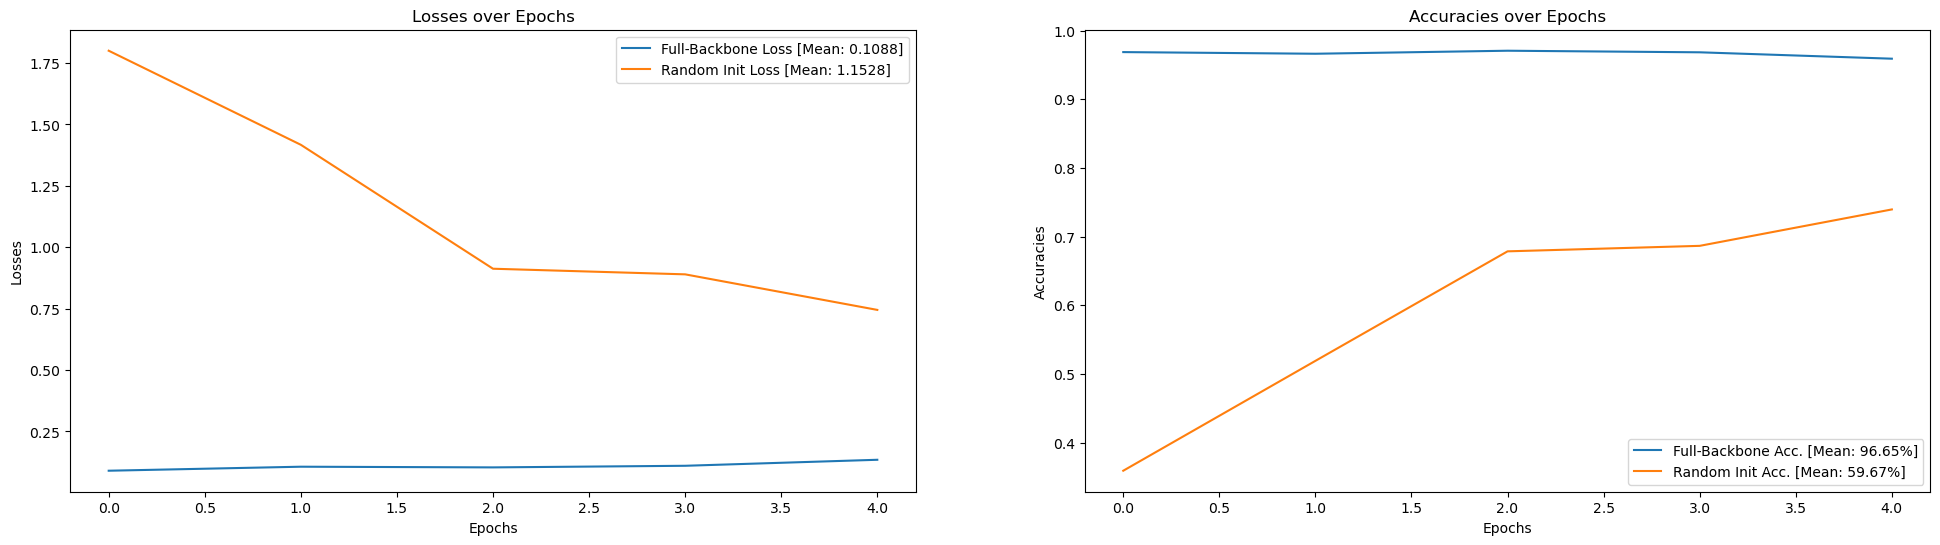

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(FULL_FINETUNED_TEST_LOSSES, label=f'Full-Backbone Loss [Mean: {np.mean(FULL_FINETUNED_TEST_LOSSES):.4f}]')
axes[0].plot(SCRATCHTRAINED_TEST_LOSSES, label=f'Random Init Loss [Mean: {np.mean(SCRATCHTRAINED_TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(FULL_FINETUNED_TEST_ACC, label=f'Full-Backbone Acc. [Mean: {(np.mean(FULL_FINETUNED_TEST_ACC) * 100):.2f}%]')
axes[1].plot(SCRATCHTRAINED_TEST_ACC, label=f'Random Init Acc. [Mean: {(np.mean(SCRATCHTRAINED_TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

**Analysis:**

Full-backbone fine-tuning and random init both train the same 58,164,298 parameters (0 percent reduction for either), so the comparison isolates the effect of initialization alone: pretrained ImageNet weights versus random weights, with everything else, including architecture, dataset, and epoch count, held fixed.

The gap this produces is large: full-backbone fine-tuning reaches roughly 96 percent validation accuracy against random init's 59.67 percent, a difference of about 36 points, purely from starting optimization at a point that already encodes generic visual features rather than at a random point in a 58-million-dimensional weight space.

Training time for both is almost comparable on a broader scale, yet there is difference in how much model learnt and improved itself.

This confirms that the benefit of pretraining is not just about how many parameters are trainable, since both models train the full network here, but about where in weight space training starts. Good initialization from a related large-scale task lets gradient descent reach a strong solution faster and more reliably than initialization from scratch, which has to rediscover both low-level filters and task-specific structure at once.

#### Collective Comparison of All Three Variants: Head-only Fine-tuned vs. Full-Backbone Fine-tuned vs. Random Init

In [48]:
print("Collective Comparison of ResNet-152 Variants: ".upper())
print("-----------------------------------------------------------------------------")
print('ResNet (Head only Fine-tuned):\n'.upper())
print("Parameters: ", paramA)
print("Trainable Parameters: ", paramTrA)
print(f"Parameters Reduction: {(paramA_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(HEAD_FINETUNED_TEST_ACC[:5]) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 39 min approx.")

print("-----------------------------------------------------------------------------")
print('ResNet (Full Backbone Fine-tuned):\n'.upper())
print("Parameters: ", paramC)
print("Trainable Parameters: ", paramTrC)
print(f"Parameters Reduction: {(paramC_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(FULL_FINETUNED_TEST_ACC) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 1 hour 43 min approx.")

print("-----------------------------------------------------------------------------")
print('ResNet (Random Init):\n'.upper())
print("Parameters: ", paramB)
print("Trainable Parameters: ", paramTrB)
print(f"Parameters Reduction: {(paramB_reduction * 100):.2f}%")
print("Epochs: 5")
print(f"Validation Accuracy: {(np.mean(SCRATCHTRAINED_TEST_ACC) * 100):.2f}%")
print(f"Training Time (avg. observed from logs): 2 hours approx.")

COLLECTIVE COMPARISON OF RESNET-152 VARIANTS: 
-----------------------------------------------------------------------------
RESNET (HEAD ONLY FINE-TUNED):

Parameters:  58164298
Trainable Parameters:  20490
Parameters Reduction: 99.96%
Epochs: 5
Validation Accuracy: 83.51%
Training Time (avg. observed from logs): 39 min approx.
-----------------------------------------------------------------------------
RESNET (FULL BACKBONE FINE-TUNED):

Parameters:  58164298
Trainable Parameters:  58164298
Parameters Reduction: 0.00%
Epochs: 5
Validation Accuracy: 96.65%
Training Time (avg. observed from logs): 1 hour 43 min approx.
-----------------------------------------------------------------------------
RESNET (RANDOM INIT):

Parameters:  58164298
Trainable Parameters:  58164298
Parameters Reduction: 0.00%
Epochs: 5
Validation Accuracy: 59.67%
Training Time (avg. observed from logs): 2 hours approx.


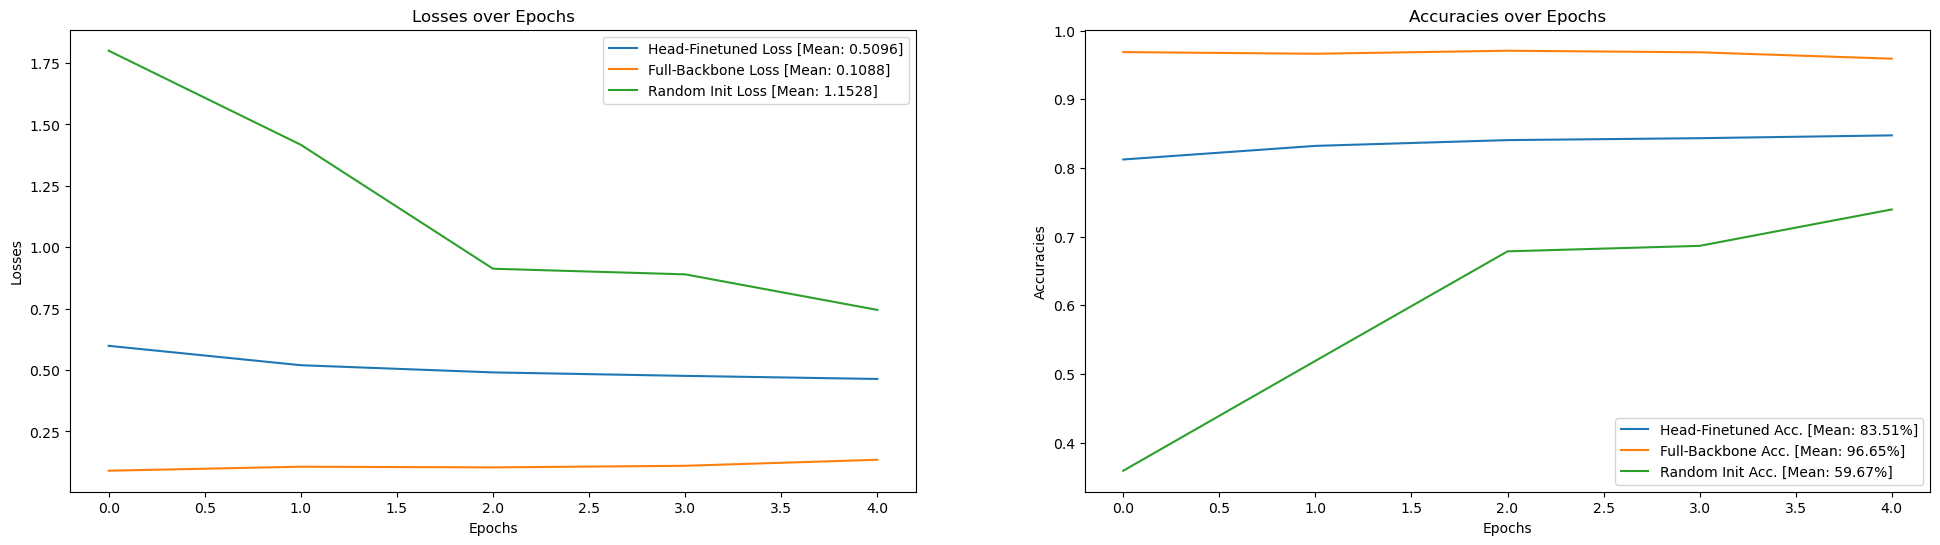

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(24,6))

axes[0].plot(HEAD_FINETUNED_TEST_LOSSES[:5], label=f'Head-Finetuned Loss [Mean: {np.mean(HEAD_FINETUNED_TEST_LOSSES[:5]):.4f}]')
axes[0].plot(FULL_FINETUNED_TEST_LOSSES, label=f'Full-Backbone Loss [Mean: {np.mean(FULL_FINETUNED_TEST_LOSSES):.4f}]')
axes[0].plot(SCRATCHTRAINED_TEST_LOSSES, label=f'Random Init Loss [Mean: {np.mean(SCRATCHTRAINED_TEST_LOSSES):.4f}]')
axes[0].set_title("Losses over Epochs")
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel("Losses")
axes[0].legend(loc='upper right')

axes[1].plot(HEAD_FINETUNED_TEST_ACC[:5], label=f'Head-Finetuned Acc. [Mean: {(np.mean(HEAD_FINETUNED_TEST_ACC[:5]) * 100):.2f}%]')
axes[1].plot(FULL_FINETUNED_TEST_ACC, label=f'Full-Backbone Acc. [Mean: {(np.mean(FULL_FINETUNED_TEST_ACC) * 100):.2f}%]')
axes[1].plot(SCRATCHTRAINED_TEST_ACC, label=f'Random Init Acc. [Mean: {(np.mean(SCRATCHTRAINED_TEST_ACC) * 100):.2f}%]')
axes[1].set_title("Accuracies over Epochs")
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel("Accuracies")
axes[1].legend(loc='lower right')

**Final Analysis:**

Across all three variants, trainable parameter count and final accuracy do not move together in a simple line: head-only trains only 0.04 percent of parameters and reaches 84.16 percent accuracy, full-backbone trains 100 percent of parameters and reaches the highest accuracy at roughly 96 percent, and random init also trains 100 percent of parameters but reaches only 59.67 percent, the lowest of the three. This shows that having more trainable capacity only helps when it starts from a useful initialization; the same 58 million trainable parameters swing between the best result and the worst result depending purely on whether they start from pretrained ImageNet weights or from random values.

Training time scales with the number of parameters being updated rather than with accuracy: head-only is fastest at about 39 minutes since gradients only touch the final linear layer, while full-backbone and random init are both far slower at about 2 hours respectively, since both propagate gradients through all 152 layers.

**Which setting gives the best compute-accuracy trade-off?** 

It depends on what is being optimized for. Full-backbone gives the highest absolute accuracy (~96%) but costs around 2 hours, about 2.6x head-only's training time, for a gain of roughly 12 points over head-only. Head-only reaches 84.16% in 39 minutes, so on an accuracy-per-minute basis it is by far the most efficient: it recovers the large majority of full-backbone's accuracy at under 40% of the compute. Random init is dominated outright, since it takes the longest to train (2 hours) and still produces the weakest model (59.67%), so there is no budget under which it is the right choice over the other two. In practice, head-only is the best trade-off when compute or time is constrained or when quick iteration matters, while full-backbone is justified only when the extra 12 points of accuracy are worth roughly 2.6x more training time, for example in a final production model where accuracy is the priority.

**Which layers are most transferable across datasets, and why?** 

The layer-wise UMAP visualization shows that separability increases monotonically with depth. Layer1 and layer2 show almost complete class intermixing, meaning the features they encode, edges, colors, simple textures, are generic and shared across virtually all natural images regardless of the specific classes involved. This is exactly why head-only fine-tuning works as well as it does: these early and mid-level filters, learned once on ImageNet, transfer almost unchanged to CIFAR-10 without needing any further adaptation. Layer3 begins forming clearer regional structure, and layer4 shows the sharpest, most class-discriminative separation, since these deeper layers encode increasingly abstract, semantic, task-specific combinations of the lower-level features. This makes layer4 the least transferable in raw form; it is tuned to ImageNet's 1000-way class structure, which is why full-backbone fine-tuning, which lets these deeper layers reorganize for CIFAR-10's 10 classes, is able to push accuracy several points beyond what a frozen backbone with a fine-tuned head alone can reach.